# KNN

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [4]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import perf_counter

from sklearn.datasets import make_moons
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from models.knn import KNN

from metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from utils.plots import plot_decision_boundary
from utils.tests import parameter_sweep_classification

## Dataset

In [ ]:
# Generation
X, y = make_moons(
    n_samples=1000,
    noise=0.25,
    random_state=42,
)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

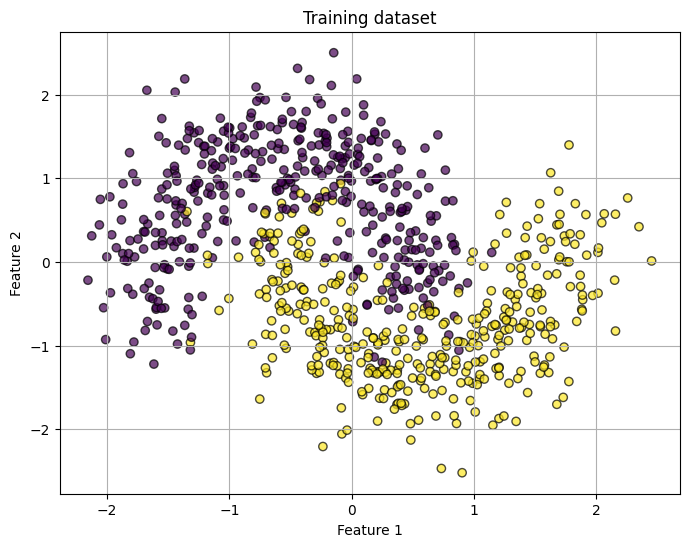

In [ ]:
# Plotting
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

## Comparison with `sklearn` model
All the models have the same metrics, but the `sklearn` one is the fastest in predicting. The *squared* model, in which I use the squared euclidean distance, thus foregoing the square root, is slightly faster than the regular model in predicting, but not by much, since the part that takes most time is actually the full sort of the samples.

In KNN, fit time is very small, while predict time is expensive, because KNN is a *lazy learner*.

In [ ]:
scratch_knn = KNN(k=5)
scratch_knn_squared = KNN(k=5, dist='squared')
sklearn_knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
models = {
    "From scratch": scratch_knn,
    "From scratch squared": scratch_knn_squared,
    "Scikit-learn": sklearn_knn,
}

results = {}

for name, model in models.items():
    start = perf_counter()
    model.fit(X_train_scaled, y_train)
    fit_time = perf_counter() - start

    start = perf_counter()
    preds = model.predict(X_test_scaled)
    predict_time = perf_counter() - start

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "Fit time": fit_time,
        "Predict time": predict_time,
    }

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,Fit time,Predict time
From scratch,0.975,0.952381,1.0,0.97561,0.000007,0.632847
From scratch squared,0.975,0.952381,1.0,0.97561,0.000003,0.602721
Scikit-learn,0.975,0.952381,1.0,0.97561,0.001170,0.001605


## Plots

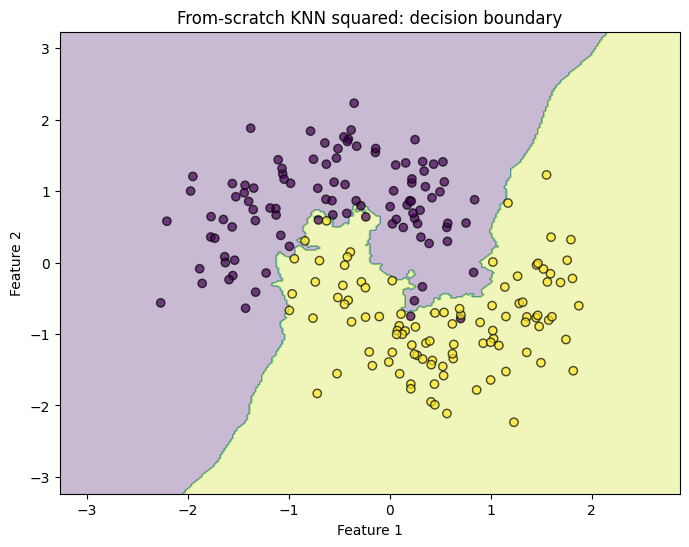

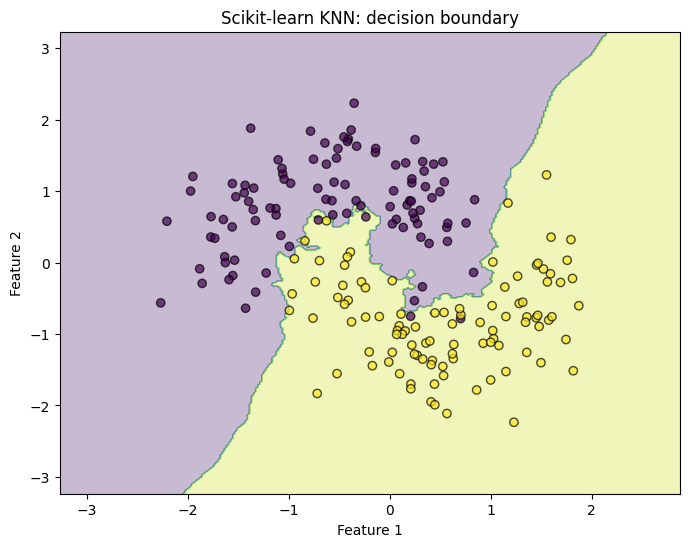

In [ ]:
# plot_decision_boundary(
#     scratch_knn,
#     X_test_scaled,
#     y_test,
#     "From-scratch KNN: decision boundary"
# )

plot_decision_boundary(
    scratch_knn_squared,
    X_test_scaled,
    y_test,
    "From-scratch KNN squared: decision boundary"
)

plot_decision_boundary(
    sklearn_knn,
    X_test_scaled,
    y_test,
    "Scikit-learn KNN: decision boundary"
)

## Harder Dataset

### Generation and Plotting

In [5]:
X, y = make_classification(
    n_samples=1500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    class_sep=0.7,
    flip_y=0.08,
    random_state=42,
)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

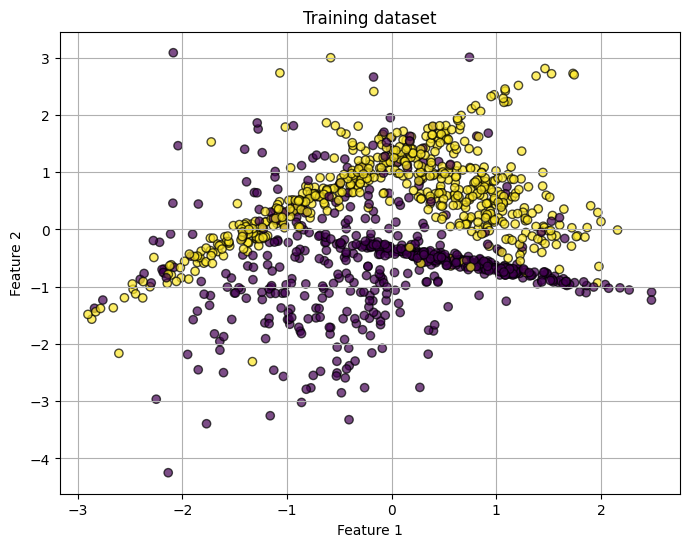

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

### Hyperparameter Sweeps

#### Number of neighbors `k`
We can see that 
- $k=1$: overfitting, basically a Voronoi tessellation of the training set
- $k=7$: best k, good smoothing
- $k=49$: underfitting

Also, precision decreases and recall increases as k grows.
The larger neighborhood makes the classifier more willing to predict the dominant class in ambiguous regions, and this shifts the balance between false positives and false negatives.

In [8]:
k_values = list(range(1, 51, 2))

rows = []

for k in k_values:
    model = KNN(k=k, dist='squared')
    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    rows.append({
        "k": k,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
    })

k_sweep_df = pd.DataFrame(rows)

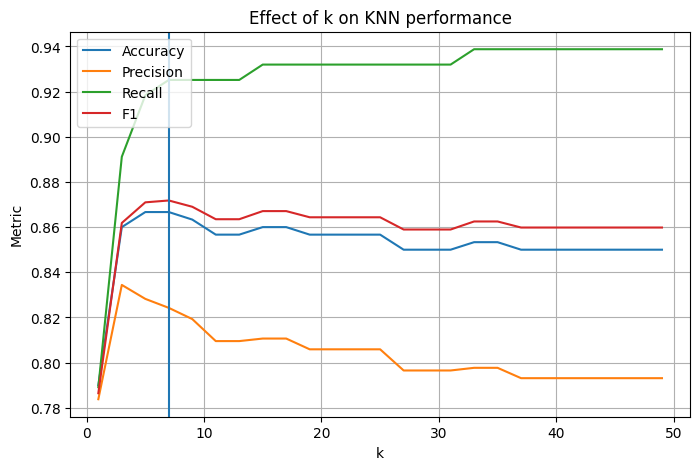

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(k_sweep_df["k"], k_sweep_df["accuracy"], label="Accuracy")
plt.plot(k_sweep_df["k"], k_sweep_df["precision"], label="Precision")
plt.plot(k_sweep_df["k"], k_sweep_df["recall"], label="Recall")
plt.plot(k_sweep_df["k"], k_sweep_df["f1"], label="F1")

plt.xlabel("k")
plt.ylabel("Metric")
plt.title("Effect of k on KNN performance")
plt.legend()
plt.grid(True)

plt.show()

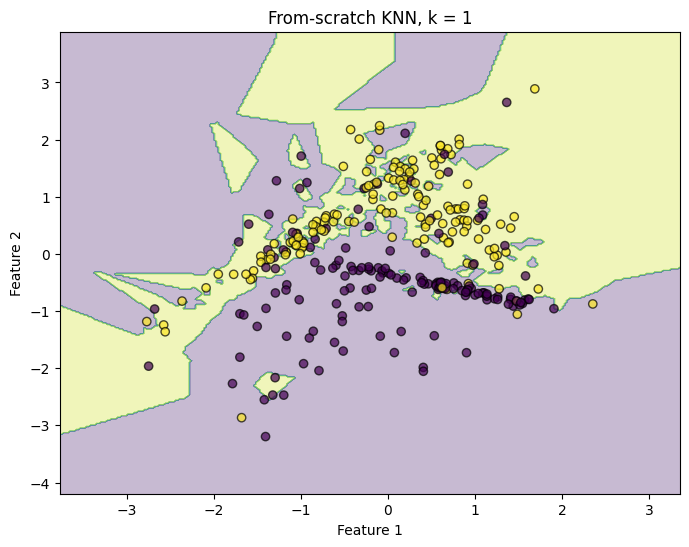

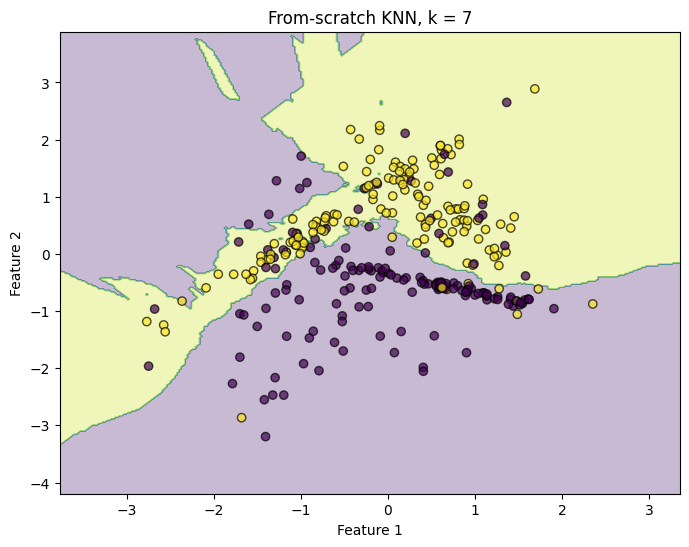

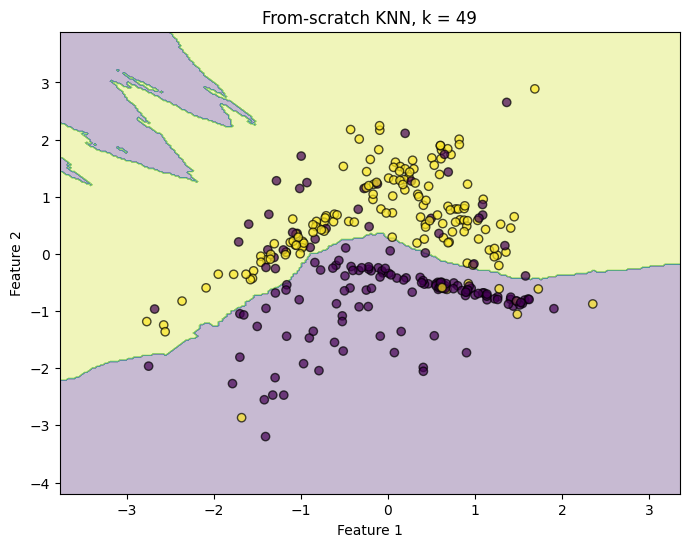

In [15]:
for k in [1, 7, 49]:
    model = KNN(k=k, dist='squared')
    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    plot_decision_boundary(
        model,
        X_test_scaled,
        y_test,
        f"From-scratch KNN, k = {k}"
    )